# Análise de Desempenho de Estudantes em Exames

Este notebook segue as etapas do projeto de árvore de decisão, utilizando o dataset 'Students Performance in Exams' do Kaggle. O objetivo é explorar, analisar e preparar os dados para classificação, seguindo o roteiro solicitado.
## 1. Importar Bibliotecas Necessárias
Vamos importar as principais bibliotecas para manipulação e visualização dos dados.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo dos gráficos
sns.set(style="whitegrid")

## 2. Carregar o Dataset

Vamos carregar o arquivo CSV do Kaggle usando pandas.

In [31]:
import kagglehub

# Baixar o dataset do Kaggle
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
print("Path to dataset files:", path)

# Carregar o arquivo CSV
csv_path = path + "/StudentsPerformance.csv"
df = pd.read_csv(csv_path)
df.head()

Path to dataset files: C:\Users\gustavo.telles\.cache\kagglehub\datasets\spscientist\students-performance-in-exams\versions\1


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Visualizar Dados Básicos

Vamos verificar o formato do dataset, os tipos de dados e se há valores nulos.

In [32]:
print('Formato do dataset:', df.shape)
df.info()
print('\nValores nulos por coluna:')
print(df.isnull().sum())

Formato do dataset: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Valores nulos por coluna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score      

## 4. Análise Exploratória dos Dados

Vamos analisar estatísticas descritivas das notas dos estudantes.

In [33]:
# Estatísticas descritivas das colunas de notas
print('Estatísticas das notas:')
df[['math score', 'reading score', 'writing score']].describe()

Estatísticas das notas:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 5. Visualização de Distribuições das Notas

Vamos visualizar a distribuição das notas em matemática, leitura e escrita usando histogramas e boxplots.

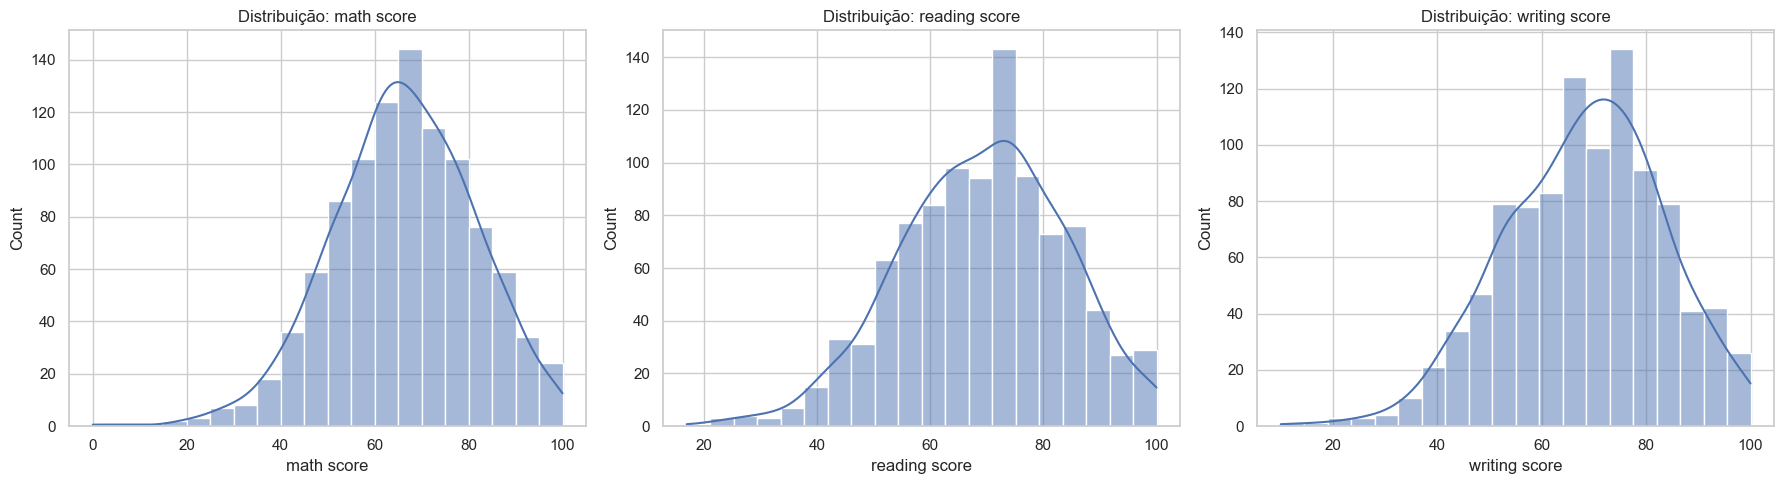

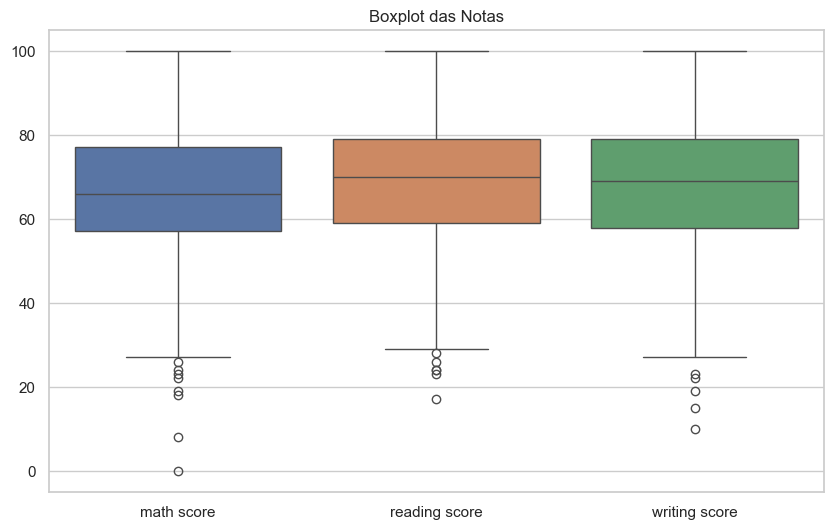

In [35]:
import os
os.makedirs('imagens', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(['math score', 'reading score', 'writing score']):
    sns.histplot(df[col], bins=20, ax=axes[idx], kde=True)
    axes[idx].set_title(f'Distribuição: {col}')
plt.tight_layout()
plt.savefig('imagens/histograma_notas.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title('Boxplot das Notas')
plt.savefig('imagens/boxplot_notas.png')
plt.show()

## 6. Correlação entre Variáveis

Vamos calcular e visualizar a matriz de correlação entre as notas e outras variáveis do dataset.

Matriz de correlação:
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


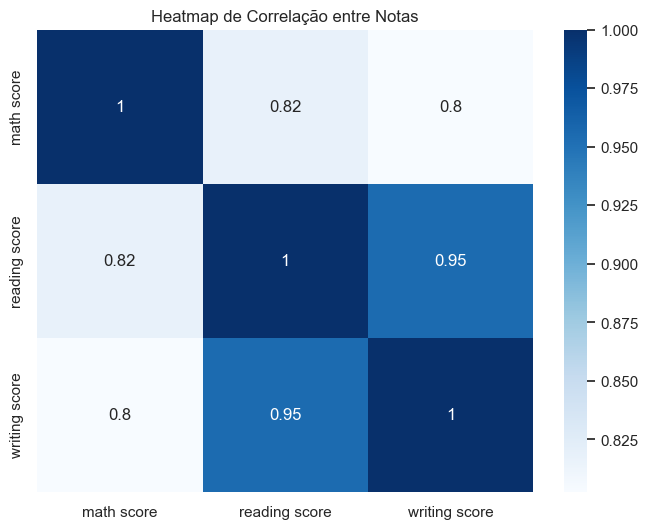

In [36]:
corr = df[['math score', 'reading score', 'writing score']].corr()
print('Matriz de correlação:')
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Heatmap de Correlação entre Notas')
plt.show()

## 7. Filtrar e Agrupar Dados por Gênero ou Grupo Étnico

Vamos comparar médias de desempenho entre diferentes grupos de estudantes.

Médias das notas por gênero:
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203

Médias das notas por grupo étnico:
                math score  reading score  writing score
race/ethnicity                                          
group A          61.629213      64.674157      62.674157
group B          63.452632      67.352632      65.600000
group C          64.463950      69.103448      67.827586
group D          67.362595      70.030534      70.145038
group E          73.821429      73.028571      71.407143


<Figure size 1000x500 with 0 Axes>

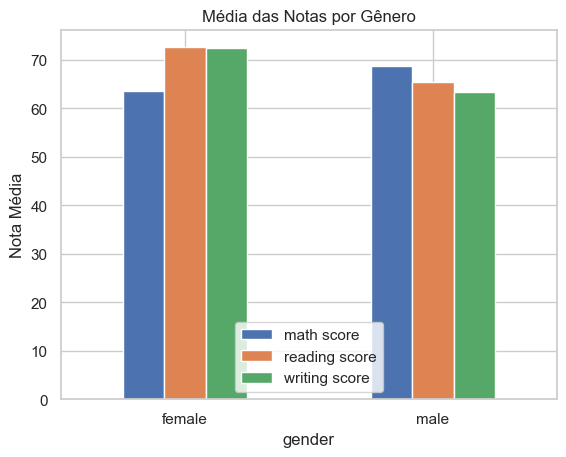

<Figure size 1000x500 with 0 Axes>

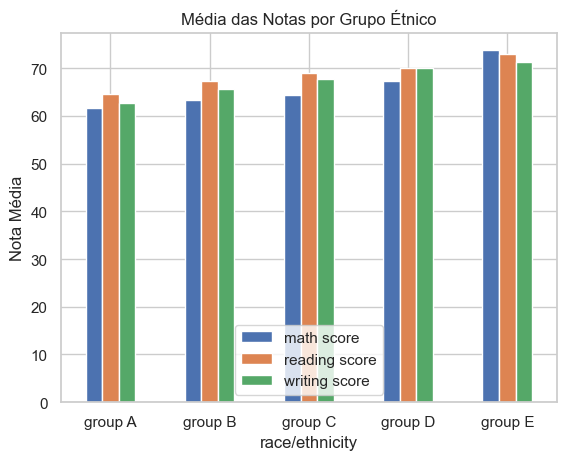

In [37]:
# Médias das notas por gênero
gender_group = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
print('Médias das notas por gênero:')
print(gender_group)

# Médias das notas por grupo étnico
ethnic_group = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()
print('\nMédias das notas por grupo étnico:')
print(ethnic_group)

# Visualização
plt.figure(figsize=(10, 5))
gender_group.plot(kind='bar')
plt.title('Média das Notas por Gênero')
plt.ylabel('Nota Média')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10, 5))
ethnic_group.plot(kind='bar')
plt.title('Média das Notas por Grupo Étnico')
plt.ylabel('Nota Média')
plt.xticks(rotation=0)
plt.show()

## 8. Pré-processamento dos Dados

Nesta etapa, vamos tratar valores ausentes (se houver), codificar variáveis categóricas e preparar os dados para o modelo de árvore de decisão.

In [38]:
# Verificar valores ausentes
print('Valores nulos por coluna:')
print(df.isnull().sum())

# Codificar variáveis categóricas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Lista de colunas categóricas
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Exemplo de dados após codificação:')
df.head()

Valores nulos por coluna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Exemplo de dados após codificação:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


## 9. Divisão dos Dados em Treino e Teste

Agora vamos separar o conjunto de dados em treino e teste para treinar e avaliar o modelo de árvore de decisão.

In [39]:
from sklearn.model_selection import train_test_split

# Selecionar features e target
X = df.drop(['math score', 'reading score', 'writing score'], axis=1)
y = df['math score']  # Exemplo: prever nota de matemática (pode ajustar para classificação)

# Para classificação, pode criar uma coluna de aprovação/reprovação, por exemplo:
# y = (df['math score'] >= 60).astype(int)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Formato treino:', X_train.shape, y_train.shape)
print('Formato teste:', X_test.shape, y_test.shape)

Formato treino: (800, 5) (800,)
Formato teste: (200, 5) (200,)


## 10. Treinamento do Modelo de Árvore de Decisão

Vamos treinar o modelo de árvore de decisão com os dados de treino.

In [40]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# Exemplo para regressão (prever nota)
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

# Exemplo para classificação (prever aprovação)
# classifier = DecisionTreeClassifier(random_state=42)
# classifier.fit(X_train, y_train)

print('Modelo treinado!')

Modelo treinado!


## 11. Avaliação do Modelo

Vamos avaliar o desempenho do modelo usando os dados de teste.

In [41]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Avaliação para regressão
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}')
print(f'R²: {r2:.2f}')

# Avaliação para classificação (se usar classifier)
# y_pred = classifier.predict(X_test)
# acc = accuracy_score(y_test, y_pred)
# print(f'Acurácia: {acc:.2f}')

MSE: 267.62
R²: -0.10


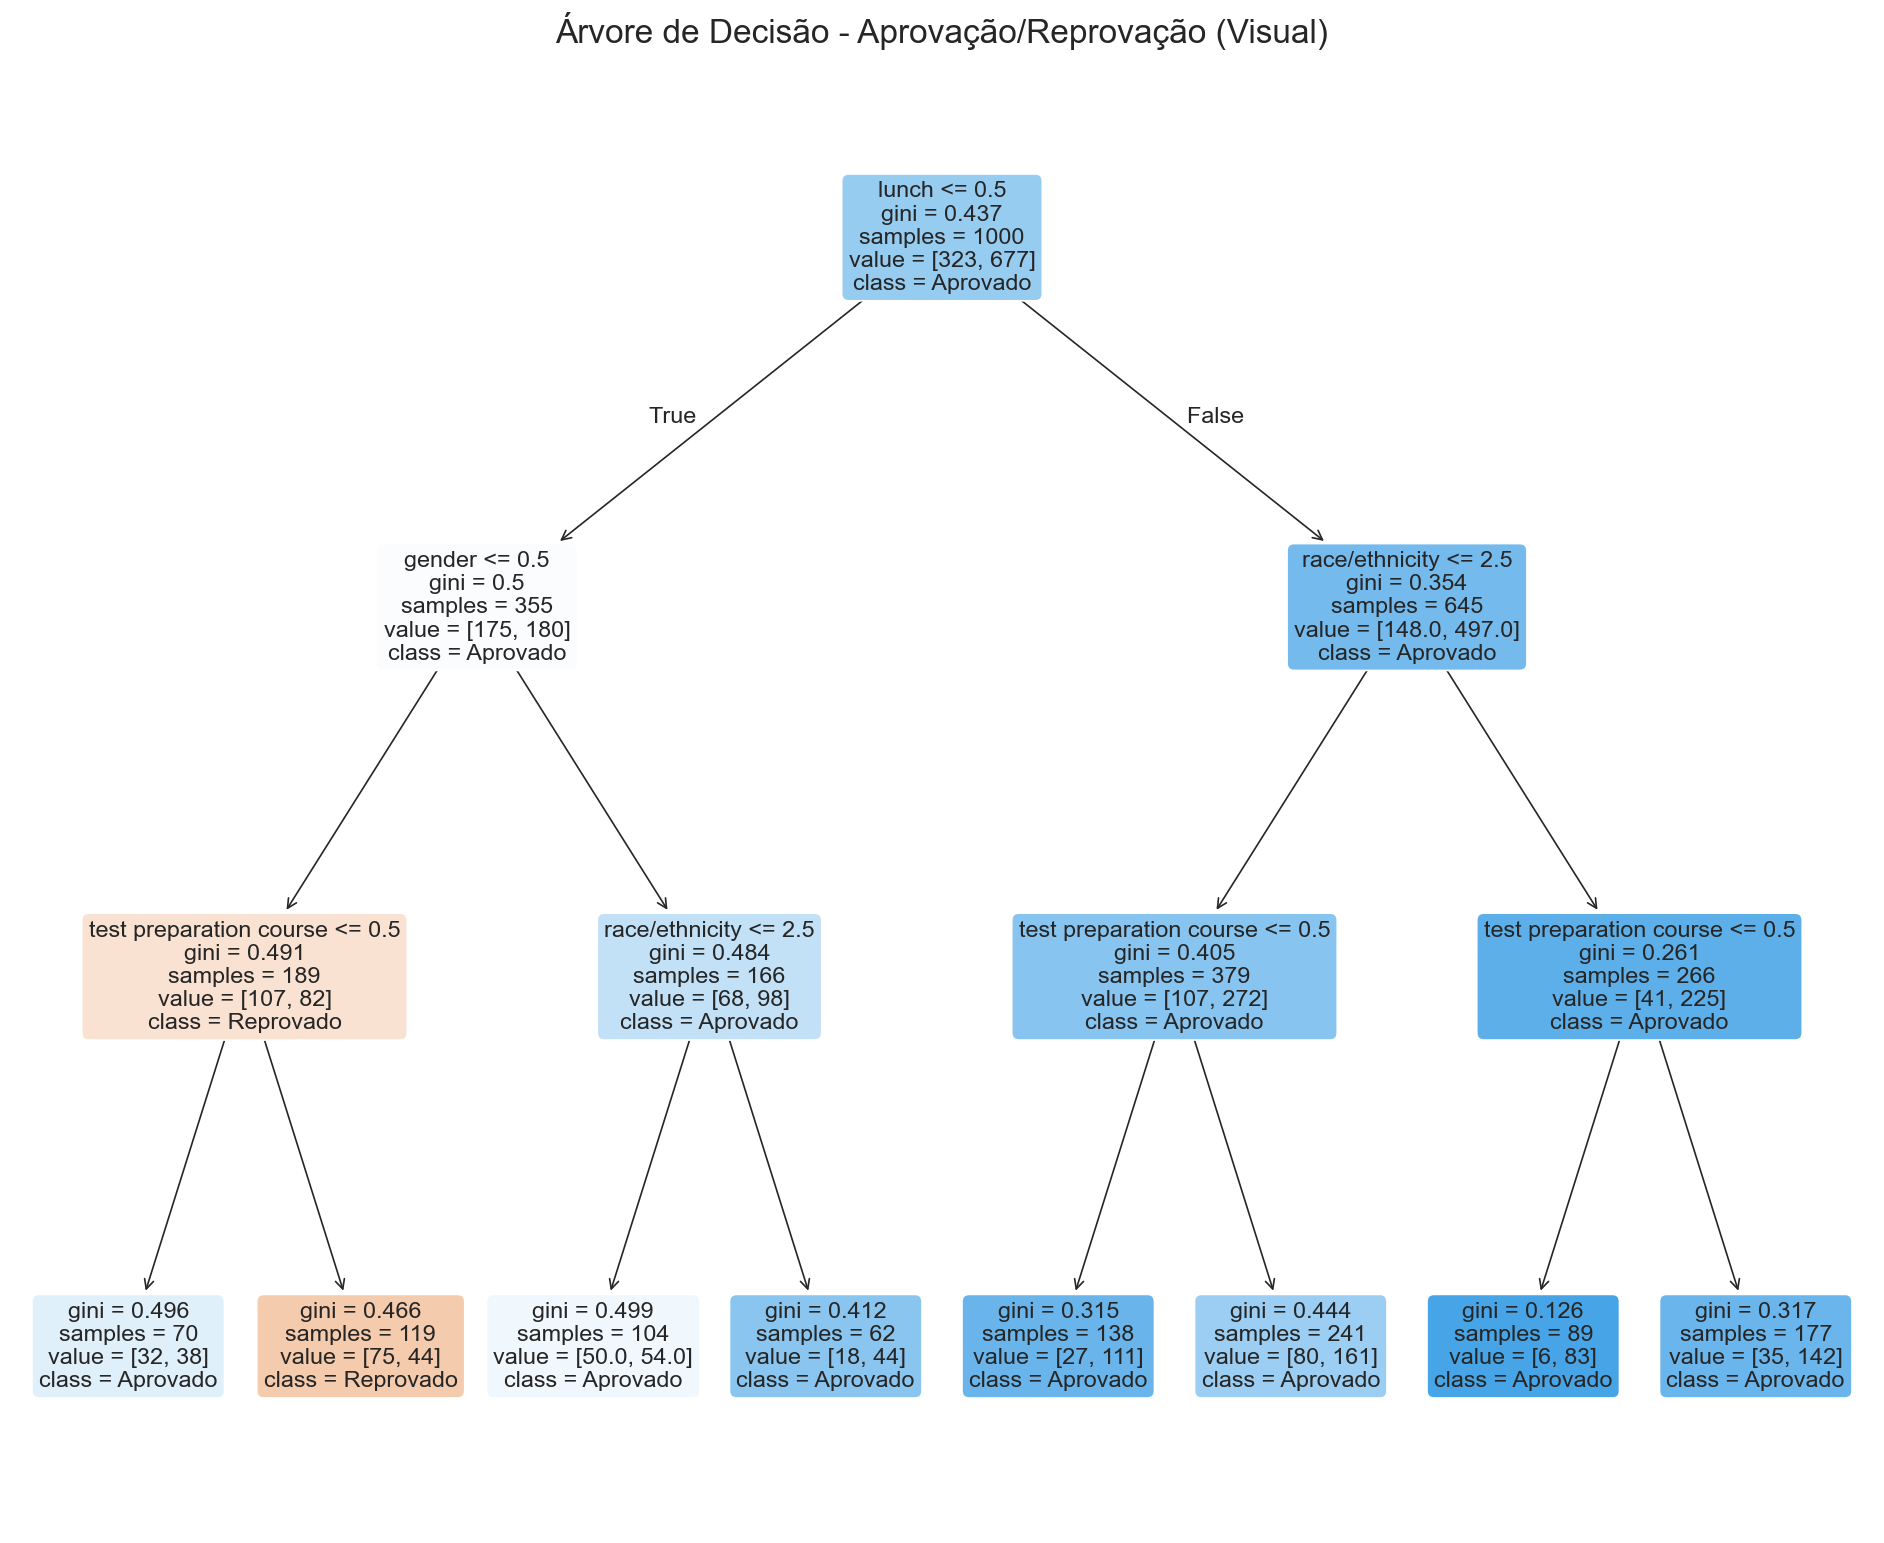

Imagem PNG salva como imagens/arvore_decisao_visual.png


In [43]:
# Árvore de decisão visual simplificada para facilitar a interpretação
from sklearn import tree
import matplotlib.pyplot as plt

# Criar variável binária para aprovação/reprovação
df['aprovado'] = (df['math score'] >= 60).astype(int)
X_visu = df[['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']]
y_visu = df['aprovado']

from sklearn.tree import DecisionTreeClassifier
clf_visu = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_visu.fit(X_visu, y_visu)

fig = plt.figure(figsize=(20, 16), dpi=120)
tree.plot_tree(
    clf_visu,
    feature_names=X_visu.columns,
    class_names=['Reprovado', 'Aprovado'],
    filled=True,
    rounded=True,
    fontsize=14
    # max_depth=3 já está no modelo
    )
plt.title('Árvore de Decisão - Aprovação/Reprovação (Visual)', fontsize=20)
plt.savefig('imagens/arvore_decisao_visual.png')
plt.show()
print('Imagem PNG salva como imagens/arvore_decisao_visual.png')

### Exemplo de Relatório Final

Neste projeto, realizamos uma análise exploratória do dataset 'Students Performance in Exams', aplicando um modelo de árvore de decisão para prever o desempenho dos estudantes. O pré-processamento incluiu a codificação de variáveis categóricas e a divisão dos dados em treino e teste. O modelo foi avaliado por métricas de regressão (MSE e R²), e a árvore foi visualizada para interpretação dos critérios de decisão.

**Possíveis melhorias:**
- Testar outros algoritmos de classificação/regressão
- Realizar tuning de hiperparâmetros
- Utilizar validação cruzada
- Explorar feature engineering

O modelo de árvore de decisão mostrou-se interpretável e útil para identificar padrões nos dados, mas pode ser aprimorado para maior robustez e desempenho.